# Music genre classification

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# load data
df = pd.read_csv('/content/drive/MyDrive/Music genre classification/features_30_sec.csv')
df.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [ ]:
# 2) Quick checks (sanity)

# shape + columns
print('Shape:', df.shape)
print('\nColumns:', list(df.columns))

# missing values
missing = df.isna().sum().sort_values(ascending=False)
print('\nMissing values (top 15):')
print(missing.head(15))

# label counts (class balance)
if 'label' in df.columns:
    print('\nLabel counts:')
    print(df['label'].value_counts())
    print('\nLabel % (normalized):')
    print((df['label'].value_counts(normalize=True) * 100).round(2))
else:
    print("\nWARNING: 'label' column not found in df")

Shape: (1000, 60)

Columns: ['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo', 'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean', 'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var', 'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean', 'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var', 'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean', 'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var', 'label']

Missing values (top 15):
filename                   0


## 3) Clean columns (avoid junk / leakage)

This dataset often contains non-feature columns like `filename` (string) and sometimes `Unnamed: 0` (an index column).

We drop them and keep only numeric feature columns + the target `label`.

In [ ]:
# Make a clean copy

df_clean = df.copy()

# Drop common non-feature columns
cols_to_drop = [c for c in ['filename', 'Unnamed: 0'] if c in df_clean.columns]
if cols_to_drop:
    df_clean = df_clean.drop(columns=cols_to_drop)
    print('Dropped columns:', cols_to_drop)

# Ensure 'label' exists
assert 'label' in df_clean.columns, "Expected a 'label' column in df"

# Keep only numeric feature columns + label
feature_cols = [c for c in df_clean.columns if c != 'label']
non_numeric = df_clean[feature_cols].select_dtypes(exclude='number').columns.tolist()
if non_numeric:
    df_clean = df_clean.drop(columns=non_numeric)
    print('Dropped non-numeric feature columns:', non_numeric)

# Drop columns that are all-missing or constant (zero variance)
feature_cols = [c for c in df_clean.columns if c != 'label']
all_nan = [c for c in feature_cols if df_clean[c].isna().all()]
zero_var = [c for c in feature_cols if df_clean[c].nunique(dropna=True) <= 1]
if all_nan or zero_var:
    df_clean = df_clean.drop(columns=all_nan + zero_var)
    print('Dropped all-NaN columns:', all_nan)
    print('Dropped constant columns:', zero_var)

print('Clean shape:', df_clean.shape)
df_clean.head()

Dropped columns: ['filename']
Clean shape: (1000, 59)


,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,3805.839606,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,3550.522098,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,3042.260232,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,2184.745799,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,3579.757627,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


## 4) Define X and y

- `y` = genre label
- `X` = all numeric audio features

In [ ]:
y = df_clean['label']
X = df_clean.drop(columns=['label'])

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Number of classes:', y.nunique())
print('Example classes:', sorted(y.unique())[:10])

X shape: (1000, 58)
y shape: (1000,)
Number of classes: 10
Example classes: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


## 5) Split data (train/val/test)

We use **stratified splits** so each genre appears in each split.

- Train: 70%
- Validation: 15%
- Test: 15%

In [ ]:
from sklearn.model_selection import train_test_split

# 70/30 first
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# split the 30% into 15% val and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print('Train:', X_train.shape, y_train.shape)
print('Val  :', X_val.shape, y_val.shape)
print('Test :', X_test.shape, y_test.shape)

# quick sanity: class distribution stays similar
print('\nTrain label counts (top 5):')
print(y_train.value_counts().head())
print('\nVal label counts (top 5):')
print(y_val.value_counts().head())
print('\nTest label counts (top 5):')
print(y_test.value_counts().head())

Train: (700, 58) (700,)
Val  : (150, 58) (150,)
Test : (150, 58) (150,)

Train label counts (top 5):
label
reggae       70
country      70
classical    70
hiphop       70
rock         70
Name: count, dtype: int64

Val label counts (top 5):
label
jazz      15
rock      15
metal     15
hiphop    15
pop       15
Name: count, dtype: int64

Test label counts (top 5):
label
disco    15
pop      15
rock     15
metal    15
jazz     15
Name: count, dtype: int64


## 6) Preprocessing

We will:

- Handle any missing values (median imputation)
- Scale features using `StandardScaler` (important for Logistic Regression / SVM)

✅ Best practice: use a **Pipeline** so preprocessing is learned only on the training set.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Optional XGBoost (we'll skip if not installed)
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False
    XGBClassifier = None

print('XGBoost available:', HAS_XGBOOST)

def make_model_pipeline(clf):
    """Simple numeric pipeline: impute -> scale -> classifier."""
    return Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', clf)
    ])

def evaluate_and_show(name, model, X_tr, y_tr, X_ev, y_ev, labels=None, show_cm=True):
    """Fit on (X_tr,y_tr), evaluate on (X_ev,y_ev)."""
    model.fit(X_tr, y_tr)
    preds = model.predict(X_ev)

    acc = accuracy_score(y_ev, preds)
    f1m = f1_score(y_ev, preds, average='macro')

    print('\n' + '=' * 70)
    print(f'Model: {name}')
    print(f'Accuracy: {acc:.4f}')
    print(f'Macro F1 : {f1m:.4f}')
    print('\nClassification report:')
    print(classification_report(y_ev, preds))

    if show_cm:
        cm = confusion_matrix(y_ev, preds, labels=labels)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                    xticklabels=labels, yticklabels=labels)
        plt.title(f'Confusion Matrix - {name}')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.show()

    return {'model': name, 'accuracy': acc, 'macro_f1': f1m, 'estimator': model}

XGBoost available: True


## 7) Baseline models (fast)

We will train a few strong baselines:

- Logistic Regression
- SVM (RBF)
- Random Forest
- (Optional) XGBoost

## 8) Evaluate properly

For **each model**, we show:

- Accuracy
- Macro F1
- Confusion matrix
- Classification report

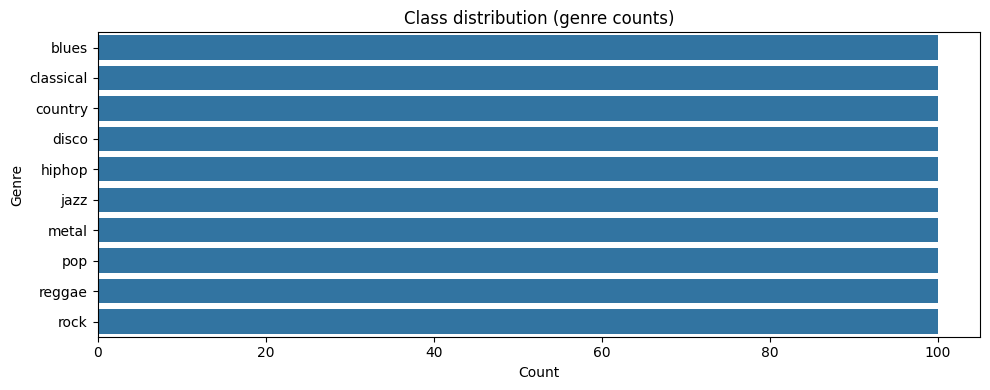

No missing values found in df_clean.


In [ ]:
# Quick plots: class distribution + missing values

plt.figure(figsize=(10, 4))
sns.countplot(y=y, order=y.value_counts().index)
plt.title('Class distribution (genre counts)')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

mv = df_clean.isna().sum()
if mv.sum() > 0:
    plt.figure(figsize=(10, 4))
    mv[mv > 0].sort_values(ascending=False).plot(kind='bar')
    plt.title('Missing values per column')
    plt.ylabel('# missing')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found in df_clean.')


Model: Logistic Regression
Accuracy: 0.7800
Macro F1 : 0.7803

Classification report:
              precision    recall  f1-score   support

       blues       0.67      0.67      0.67        15
   classical       1.00      1.00      1.00        15
     country       0.67      0.67      0.67        15
       disco       0.85      0.73      0.79        15
      hiphop       0.71      0.80      0.75        15
        jazz       0.87      0.87      0.87        15
       metal       0.80      0.80      0.80        15
         pop       0.93      0.87      0.90        15
      reggae       0.71      0.80      0.75        15
        rock       0.64      0.60      0.62        15

    accuracy                           0.78       150
   macro avg       0.78      0.78      0.78       150
weighted avg       0.78      0.78      0.78       150



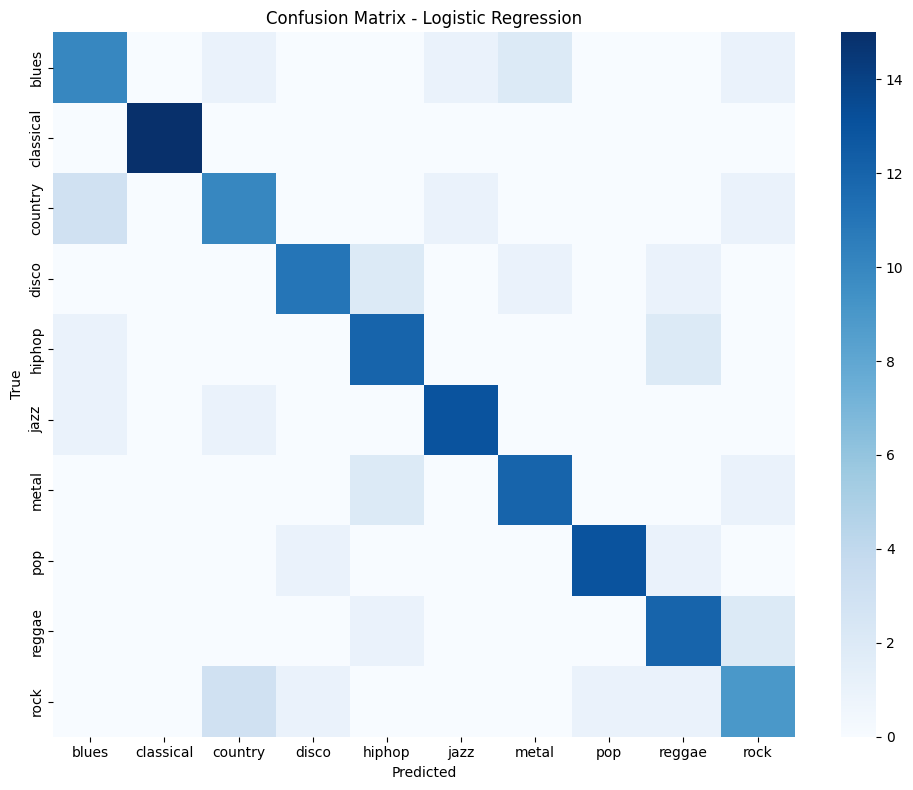


Model: SVM (RBF)
Accuracy: 0.7533
Macro F1 : 0.7558

Classification report:
              precision    recall  f1-score   support

       blues       0.79      0.73      0.76        15
   classical       1.00      1.00      1.00        15
     country       0.92      0.80      0.86        15
       disco       0.50      0.53      0.52        15
      hiphop       0.79      0.73      0.76        15
        jazz       0.82      0.93      0.88        15
       metal       0.69      0.73      0.71        15
         pop       0.92      0.73      0.81        15
      reggae       0.65      0.73      0.69        15
        rock       0.56      0.60      0.58        15

    accuracy                           0.75       150
   macro avg       0.76      0.75      0.76       150
weighted avg       0.76      0.75      0.76       150



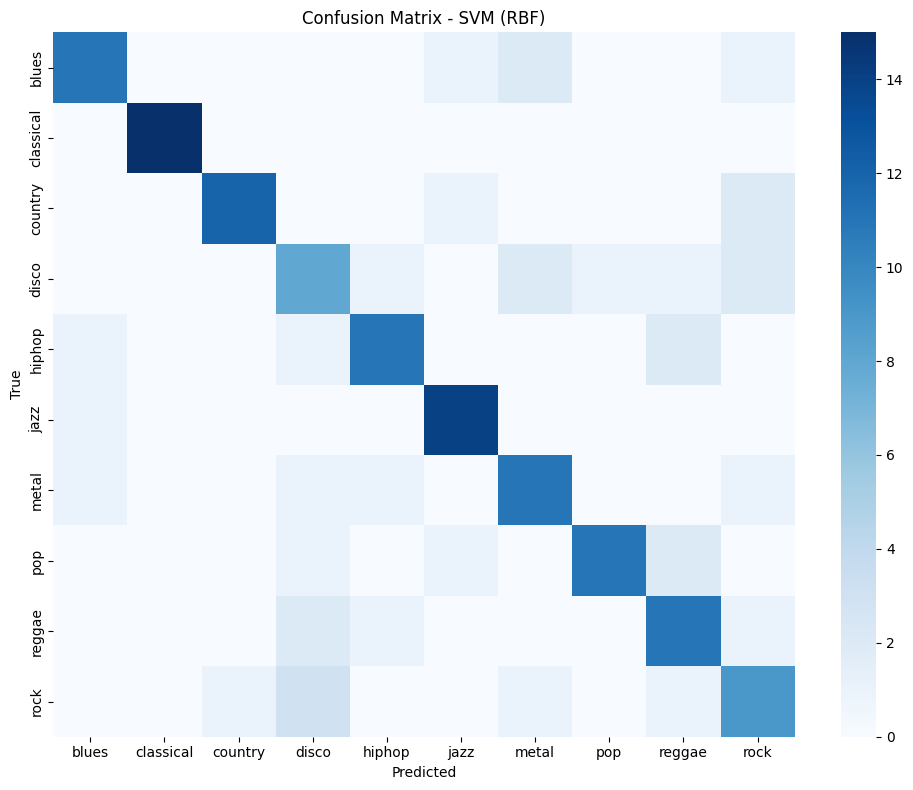


Model: Random Forest
Accuracy: 0.8667
Macro F1 : 0.8671

Classification report:
              precision    recall  f1-score   support

       blues       0.80      0.80      0.80        15
   classical       1.00      1.00      1.00        15
     country       0.92      0.80      0.86        15
       disco       0.76      0.87      0.81        15
      hiphop       0.75      0.80      0.77        15
        jazz       1.00      0.93      0.97        15
       metal       0.93      0.87      0.90        15
         pop       0.88      1.00      0.94        15
      reggae       0.86      0.80      0.83        15
        rock       0.80      0.80      0.80        15

    accuracy                           0.87       150
   macro avg       0.87      0.87      0.87       150
weighted avg       0.87      0.87      0.87       150



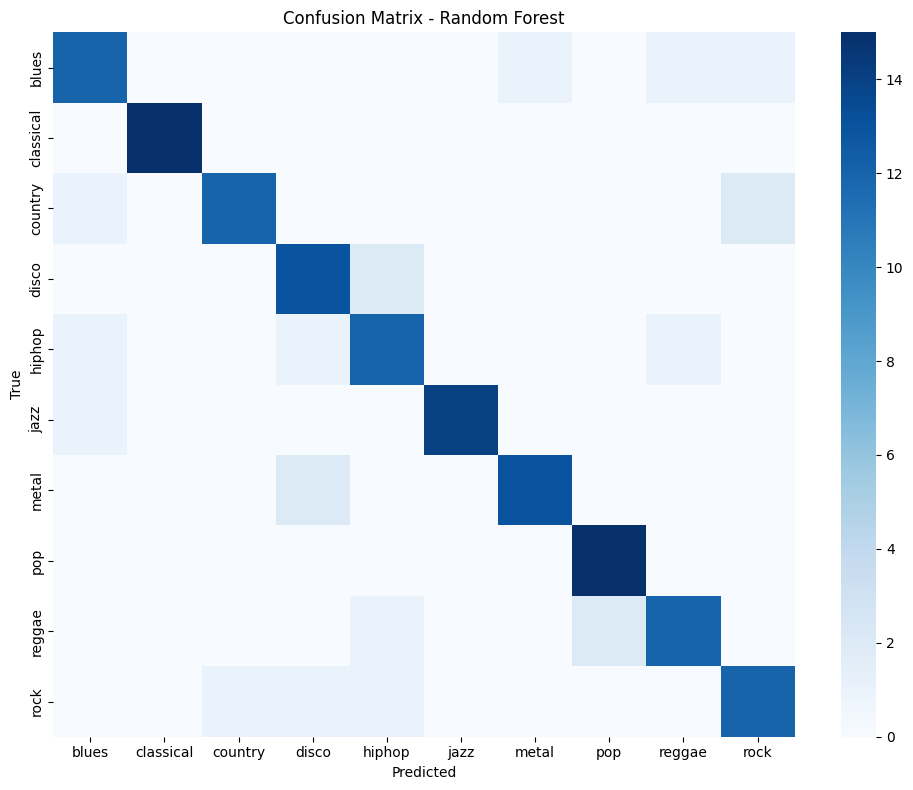


Model: XGBoost
Accuracy: 0.8333
Macro F1 : 0.8328

Classification report:
              precision    recall  f1-score   support

       blues       0.80      0.80      0.80        15
   classical       1.00      0.93      0.97        15
     country       0.87      0.87      0.87        15
       disco       0.67      0.80      0.73        15
      hiphop       0.79      0.73      0.76        15
        jazz       0.83      1.00      0.91        15
       metal       0.92      0.80      0.86        15
         pop       0.88      0.93      0.90        15
      reggae       0.80      0.80      0.80        15
        rock       0.83      0.67      0.74        15

    accuracy                           0.83       150
   macro avg       0.84      0.83      0.83       150
weighted avg       0.84      0.83      0.83       150



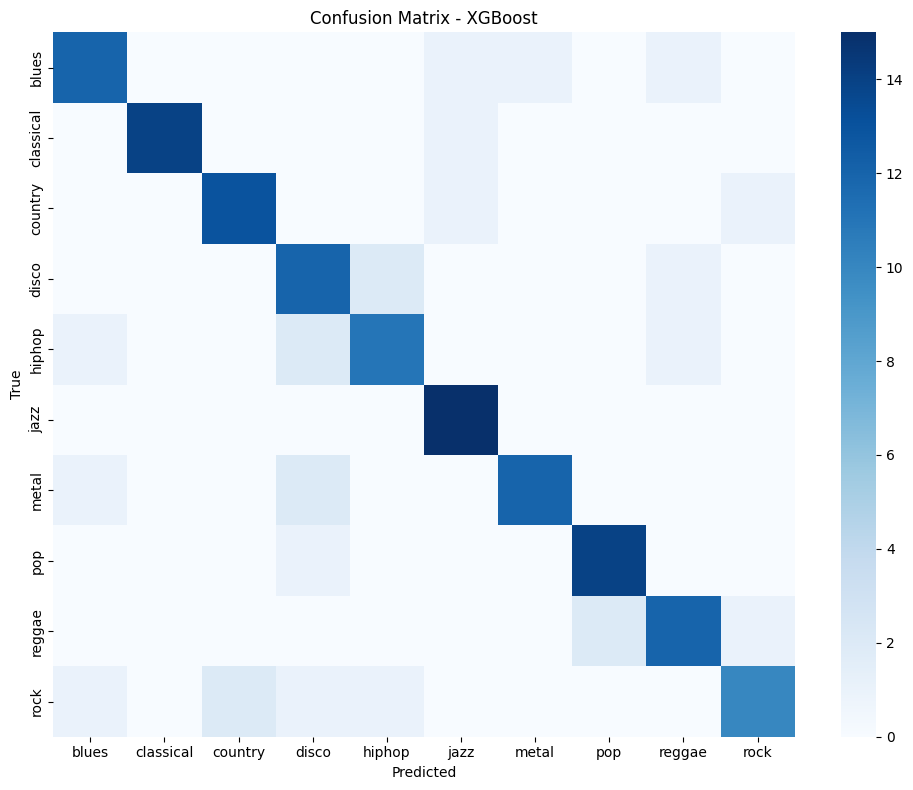

,model,accuracy,macro_f1
0,Random Forest,0.866667,0.867099
1,XGBoost,0.833333,0.832828
2,Logistic Regression,0.780000,0.780296
3,SVM (RBF),0.753333,0.755815


In [ ]:
# Train & evaluate baseline models on the validation set

labels_sorted = sorted(y.unique())

results = []

# Logistic Regression
log_reg = make_model_pipeline(
    LogisticRegression(max_iter=5000, n_jobs=None)  # keep simple, works well here
)
results.append(evaluate_and_show('Logistic Regression', log_reg, X_train, y_train, X_val, y_val, labels=labels_sorted))

# SVM (RBF)
svm_rbf = make_model_pipeline(
    SVC(kernel='rbf')
)
results.append(evaluate_and_show('SVM (RBF)', svm_rbf, X_train, y_train, X_val, y_val, labels=labels_sorted))

# Random Forest (tree-based)
rf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])
results.append(evaluate_and_show('Random Forest', rf, X_train, y_train, X_val, y_val, labels=labels_sorted))

# Optional: XGBoost
if HAS_XGBOOST:
    from sklearn.preprocessing import LabelEncoder

    le = LabelEncoder()
    y_train_xgb = le.fit_transform(y_train)
    y_val_xgb = le.transform(y_val)

    xgb = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', XGBClassifier(
            n_estimators=600,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            objective='multi:softmax',
            num_class=len(le.classes_),
            eval_metric='mlogloss',
            random_state=42
        ))
    ])

    # custom eval for encoded labels
    xgb.fit(X_train, y_train_xgb)
    preds_xgb = xgb.predict(X_val)
    preds_xgb = le.inverse_transform(preds_xgb)

    acc = accuracy_score(y_val, preds_xgb)
    f1m = f1_score(y_val, preds_xgb, average='macro')

    print('\n' + '=' * 70)
    print('Model: XGBoost')
    print(f'Accuracy: {acc:.4f}')
    print(f'Macro F1 : {f1m:.4f}')
    print('\nClassification report:')
    print(classification_report(y_val, preds_xgb))

    cm = confusion_matrix(y_val, preds_xgb, labels=labels_sorted)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                xticklabels=labels_sorted, yticklabels=labels_sorted)
    plt.title('Confusion Matrix - XGBoost')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    results.append({'model': 'XGBoost', 'accuracy': acc, 'macro_f1': f1m, 'estimator': xgb, 'label_encoder': le})
else:
    print('\nXGBoost not installed -> skipping XGBoost baseline.')

# Summary table
results_df = pd.DataFrame([{k: r[k] for k in ['model', 'accuracy', 'macro_f1']} for r in results])
results_df = results_df.sort_values(by='macro_f1', ascending=False).reset_index(drop=True)
results_df

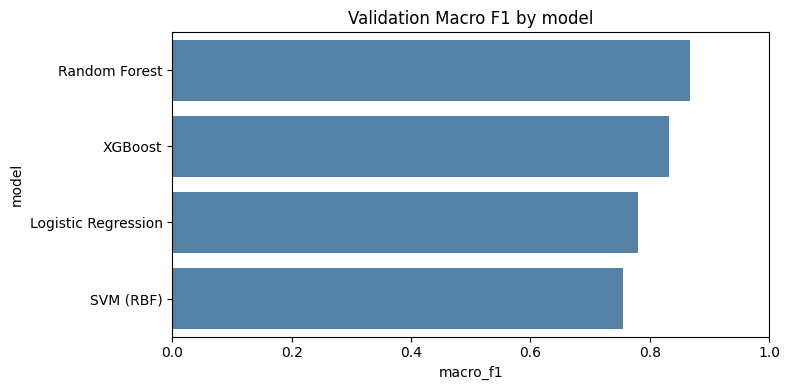

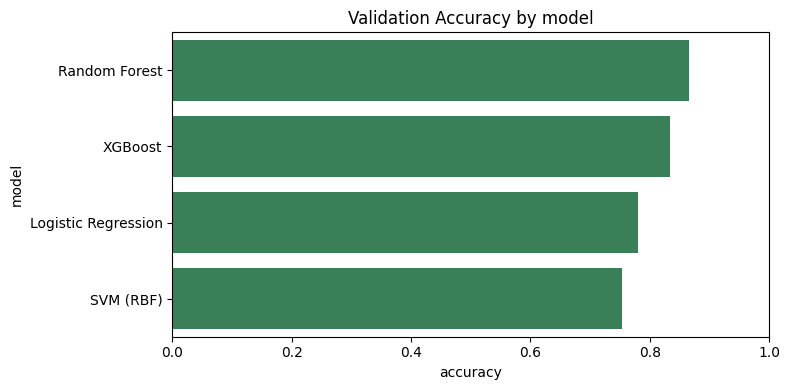

In [ ]:
# Plot model comparison (validation performance)

plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x='macro_f1', y='model', color='steelblue')
plt.title('Validation Macro F1 by model')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x='accuracy', y='model', color='seagreen')
plt.title('Validation Accuracy by model')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## 9) Hyperparameter tuning (make it strong)

We tune the best baseline model (by **validation Macro F1**) using `RandomizedSearchCV`.

✅ We tune on the **training set** with cross-validation, then evaluate the tuned model on the **validation set**.

Then we pick the best final model and evaluate **once** on the test set.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold

# Pick the best baseline by Macro F1
best_baseline_name = results_df.loc[0, 'model']
print('Best baseline (val macro F1):', best_baseline_name)

# Helper: get estimator record
def get_result_record(model_name):
    for r in results:
        if r['model'] == model_name:
            return r
    raise ValueError('Model not found in results: ' + model_name)

best_record = get_result_record(best_baseline_name)

# Define search space depending on model
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

if best_baseline_name == 'SVM (RBF)':
    estimator = best_record['estimator']
    param_distributions = {
        'clf__C': np.logspace(-1, 2, 20),
        'clf__gamma': np.logspace(-4, -1, 20)
    }
    scoring = 'f1_macro'

elif best_baseline_name == 'Logistic Regression':
    estimator = best_record['estimator']
    param_distributions = {
        'clf__C': np.logspace(-2, 2, 30)
    }
    scoring = 'f1_macro'

elif best_baseline_name == 'Random Forest':
    estimator = best_record['estimator']
    param_distributions = {
        'clf__n_estimators': [200, 400, 700, 1000],
        'clf__max_depth': [None, 10, 20, 30, 40],
        'clf__min_samples_split': [2, 5, 10],
        'clf__min_samples_leaf': [1, 2, 4]
    }
    scoring = 'f1_macro'

elif best_baseline_name == 'XGBoost':
    # For XGBoost we tune a new estimator with encoded labels
    from sklearn.preprocessing import LabelEncoder

    le_tune = best_record.get('label_encoder', None)
    if le_tune is None:
        le_tune = LabelEncoder().fit(y_train)

    y_train_tune = le_tune.transform(y_train)

    estimator = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', XGBClassifier(
            objective='multi:softprob',
            num_class=len(le_tune.classes_),
            eval_metric='mlogloss',
            random_state=42
        ))
    ])

    param_distributions = {
        'clf__n_estimators': [300, 600, 900],
        'clf__max_depth': [3, 5, 7, 9],
        'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'clf__subsample': [0.7, 0.85, 1.0],
        'clf__colsample_bytree': [0.7, 0.85, 1.0]
    }
    scoring = 'f1_macro'  # we'll compute f1_macro manually later on val

else:
    raise ValueError('No tuning setup for model: ' + best_baseline_name)

search = RandomizedSearchCV(
    estimator=estimator,
    param_distributions=param_distributions,
    n_iter=20,
    scoring=scoring,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

if best_baseline_name == 'XGBoost':
    search.fit(X_train, y_train_tune)
else:
    search.fit(X_train, y_train)

print('Best CV score:', search.best_score_)
print('Best params:', search.best_params_)

Best baseline (val macro F1): Random Forest
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best CV score: 0.7654251975963443
Best params: {'clf__n_estimators': 700, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': 20}


TUNED MODEL: Random Forest
Val Accuracy: 0.8400
Val Macro F1 : 0.8406

Classification report (validation):
              precision    recall  f1-score   support

       blues       0.76      0.87      0.81        15
   classical       1.00      0.93      0.97        15
     country       0.86      0.80      0.83        15
       disco       0.75      0.80      0.77        15
      hiphop       0.71      0.80      0.75        15
        jazz       0.88      0.93      0.90        15
       metal       1.00      0.80      0.89        15
         pop       0.88      1.00      0.94        15
      reggae       0.92      0.80      0.86        15
        rock       0.71      0.67      0.69        15

    accuracy                           0.84       150
   macro avg       0.85      0.84      0.84       150
weighted avg       0.85      0.84      0.84       150



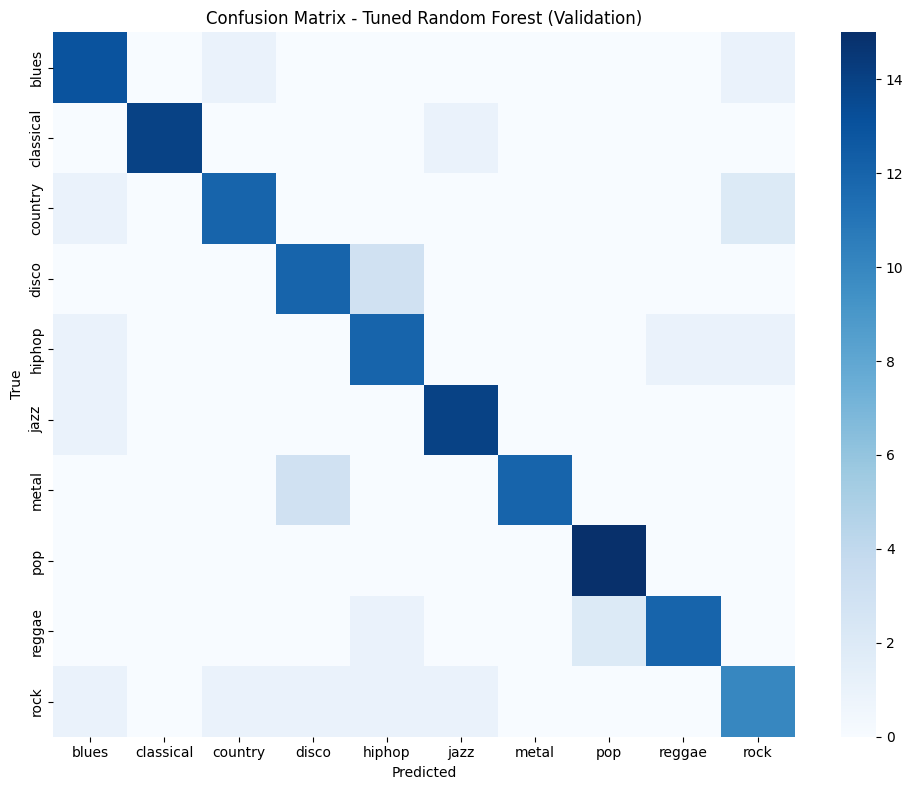

In [ ]:
# Evaluate tuned model on validation set

if best_baseline_name == 'XGBoost':
    tuned_model = search.best_estimator_
    preds_val = tuned_model.predict(X_val)
    preds_val = le_tune.inverse_transform(preds_val.astype(int))
else:
    tuned_model = search.best_estimator_
    preds_val = tuned_model.predict(X_val)

val_acc = accuracy_score(y_val, preds_val)
val_f1m = f1_score(y_val, preds_val, average='macro')

print('TUNED MODEL:', best_baseline_name)
print(f'Val Accuracy: {val_acc:.4f}')
print(f'Val Macro F1 : {val_f1m:.4f}')

print('\nClassification report (validation):')
print(classification_report(y_val, preds_val))

cm = confusion_matrix(y_val, preds_val, labels=labels_sorted)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.title(f'Confusion Matrix - Tuned {best_baseline_name} (Validation)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## 10) Final test evaluation (evaluate ONCE)

Now we refit the tuned model using **Train + Validation**, then evaluate **one time** on the untouched **Test** set.

FINAL TEST RESULTS
Final model: Random Forest
Test Accuracy: 0.7867
Test Macro F1 : 0.7834

Classification report (test):
              precision    recall  f1-score   support

       blues       0.86      0.80      0.83        15
   classical       0.78      0.93      0.85        15
     country       0.69      0.73      0.71        15
       disco       0.85      0.73      0.79        15
      hiphop       0.80      0.80      0.80        15
        jazz       0.71      0.80      0.75        15
       metal       0.88      0.93      0.90        15
         pop       0.93      0.87      0.90        15
      reggae       0.75      0.80      0.77        15
        rock       0.64      0.47      0.54        15

    accuracy                           0.79       150
   macro avg       0.79      0.79      0.78       150
weighted avg       0.79      0.79      0.78       150



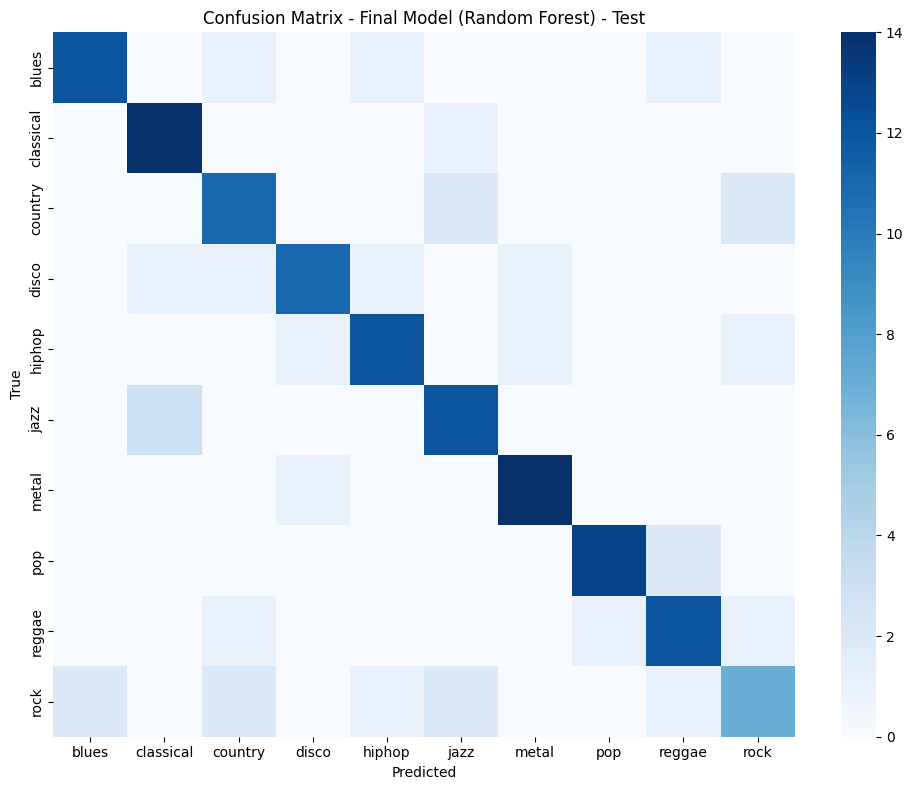

In [ ]:
# Refit on Train + Val, evaluate once on Test

X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

final_model = search.best_estimator_

if best_baseline_name == 'XGBoost':
    # refit with encoded labels
    from sklearn.preprocessing import LabelEncoder

    le_final = le_tune  # reuse encoder from tuning
    y_trainval_enc = le_final.transform(y_trainval)
    final_model.fit(X_trainval, y_trainval_enc)

    preds_test = final_model.predict(X_test)
    preds_test = le_final.inverse_transform(preds_test.astype(int))
else:
    final_model.fit(X_trainval, y_trainval)
    preds_test = final_model.predict(X_test)

test_acc = accuracy_score(y_test, preds_test)
test_f1m = f1_score(y_test, preds_test, average='macro')

print('FINAL TEST RESULTS')
print('Final model:', best_baseline_name)
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Macro F1 : {test_f1m:.4f}')

print('\nClassification report (test):')
print(classification_report(y_test, preds_test))

cm = confusion_matrix(y_test, preds_test, labels=labels_sorted)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.title(f'Confusion Matrix - Final Model ({best_baseline_name}) - Test')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## 11) Interpretation (feature importance)

- For **Logistic Regression**: coefficients show which features push predictions.
- For **Random Forest / XGBoost**: `feature_importances_` gives feature impact.

We’ll plot the top features (easy + recruiter-friendly).

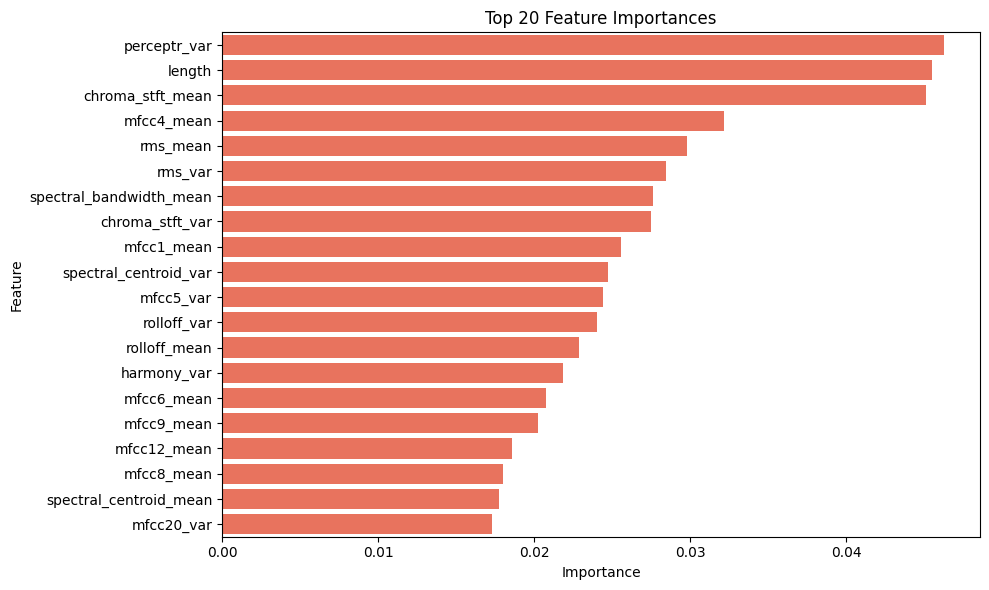

In [ ]:
feature_names = X.columns.tolist()

# Extract the fitted classifier from the pipeline
clf = final_model.named_steps.get('clf', final_model)

if hasattr(clf, 'feature_importances_'):
    importances = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)
    top = importances.head(20)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top.values, y=top.index, color='tomato')
    plt.title('Top 20 Feature Importances')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

elif hasattr(clf, 'coef_'):
    # Multiclass: coef_ shape = (n_classes, n_features)
    coef_abs_mean = np.mean(np.abs(clf.coef_), axis=0)
    coef_series = pd.Series(coef_abs_mean, index=feature_names).sort_values(ascending=False)
    top = coef_series.head(20)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top.values, y=top.index, color='purple')
    plt.title('Top 20 Features by |Coefficient| (avg across classes)')
    plt.xlabel('Average |coefficient|')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

else:
    print('This model does not support simple feature importance/coefficient extraction.')

## Conclusion

In this notebook we:

- Verified the dataset (shape, columns, missing values, class balance)
- Cleaned non-feature columns (like `filename`)
- Created stratified Train/Val/Test splits
- Trained strong baseline models
- Tuned the best model and evaluated it once on the test set
- Added plots for class balance, model comparison, confusion matrices, and top features

✅ Your final numbers are printed in **FINAL TEST RESULTS** above (Accuracy + Macro F1 + full classification report).

In [ ]:
# Optional: save the final model (so this becomes a real project artifact)

import joblib

out_path = 'music_genre_model.joblib'
joblib.dump(
    {
        'model_name': best_baseline_name,
        'model': final_model,
        'feature_names': feature_names,
        'labels': labels_sorted,
        # if we used XGBoost with encoding, keep the encoder
        'label_encoder': (le_final if best_baseline_name == 'XGBoost' else None)
    },
    out_path
)
print('Saved model to:', out_path)

Saved model to: music_genre_model.joblib
